**Import Liorangeraries**

In [16]:
from libraries import*
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
import sympy as sym
from sympy import *
from matplotlib.lines import Line2D

In [17]:
w0 = 81.356 # larmor frequency for 17O
df = [0]*6
# Data for L-alanine
df[0] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/L_ala_all_site.xlsx', sheet_name='all_site_x')
df[1] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/L_ala_all_site.xlsx', sheet_name='all_site_y')
df[2] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/L_ala_all_site.xlsx', sheet_name='all_site_z')

# Data for D-alanine
df[3] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/D_ala_all_site.xlsx', sheet_name='all_site_x')
df[4] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/D_ala_all_site.xlsx', sheet_name='all_site_y')
df[5] = pd.read_excel('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/D_ala_all_site.xlsx', sheet_name='all_site_z')




In [3]:
print(df[0])

    site  ax  angle  mval    site1    site2    site3    site4    site5  \
0      1   1    0.0   0.5   6.8251  18.0578   7.6202  28.0947  28.4118   
1      1   1   15.0   0.5  12.5868   8.2219   9.1592  20.1483  22.8020   
2      1   1   30.0   0.5  18.1278   5.4778  10.5714   9.2656  14.8967   
3      1   1   45.0   0.5  18.1278  14.8967  11.4769   5.4778  11.4769   
4      1   1   60.0   0.5  14.2280  21.8138  12.8911   7.7959  17.4311   
5      1   1   75.0   0.5  11.1941  25.0668  12.5657  10.9112  24.2508   
6      1   1   90.0   0.5  13.5379  20.6552  12.7840   9.8616  24.8187   
7      1   1  105.0   0.5  19.9038  14.7645  11.7551   5.8359  17.3557   
8      1   1  120.0   0.5  23.2946  14.9889   9.4878   4.6149   8.4258   
9      1   1  135.0   0.5  20.3501  22.1621   7.7674  10.0715   6.7576   
10     1   1  150.0   0.5  12.4078  29.0037   6.5926  20.5208  14.3006   
11     1   1  165.2   0.5   6.6444  27.7185   6.2207  28.7599  24.2316   
12     1   1  180.0   0.5   7.0173  17

**For l-alanine**

In [4]:

L_alanine_x = [[14.737690, -3.367975, -1.051694, -4.514505, 4.254813], 
          [15.103190, -3.049508, 0.265975, -4.809242, 5.089568],
          [17.921716, 1.689737, 2.618147 ,8.682148 ,-2.390272],
          [11.365380 ,4.518315 ,-4.754899 ,1.772467 ,-5.416632],
          [18.570676 ,-1.186278 ,-4.394504 ,0.646455 ,-8.693795],
          [13.461091 ,9.159257 ,-2.221009 ,5.723060 ,-4.050988],
          [9.898037 ,-2.604969 ,1.996680 ,0.187430 ,0.391153],
          [8.949841 ,-2.688433 ,1.820286 ,0.332757 ,0.188034]
          ]                                                     # coefficient from ASICS
L_alanine_y = [[20.193301, -1.059327, 3.902351, 8.084689, 2.587131], 
          [17.782857, 3.539169, -3.806900, 7.413127, -1.810766],
          [13.695140, -2.991692, -4.764808, -2.608292, -1.801069],
          [14.222501, -3.345739, -3.125448, -3.540604, -1.750292],
          [17.039316,-3.575860, 3.846696, -6.802925, 0.813860],
          [16.124429, -3.595154, 2.313071, -5.841314, 3.206572],
          [17.824127, -5.530042, -1.831449, 5.762191, -4.372375],
          [14.048123 ,-2.324625 ,0.209704 ,5.407000, 1.755148]
          ]                                                     # coefficient from ASICS

L_alanine_z = [[20.558615, 10.925393, 2.993615, 0.085703, 0.151495], 
          [19.354774, 9.263824, 0.308747 ,0.971616 ,0.522957],
          [18.646494, -0.237855 ,-10.114529, -1.172745, 0.003156],
          [20.189030, -2.811494, -11.398299, 0.125070, 0.289326],
          [13.791981, 1.359722, -1.271154, 0.003027, 1.995557],
          [13.305829, 0.386885, -0.627588, 0.811854, -0.167208],
          [13.545094, 0.017761, 0.063526, 0.005215, -0.666844],
          [12.845862, 1.352869, 0.014427, -1.037532, -0.713633]
          ]                                                     # coefficient from ASICS

# # Fit for Mounting 1

angle_smooth = np.linspace(df[0].angle.min(), df[0].angle.max(), 100) #100 points for smooth curve
L_alanine_1_x = fourier5(angle_smooth, *L_alanine_x[0])
L_alanine_2_x = fourier5(angle_smooth, *L_alanine_x[1])
L_alanine_3_x = fourier5(angle_smooth, *L_alanine_x[2])
L_alanine_4_x = fourier5(angle_smooth, *L_alanine_x[3])
L_alanine_5_x = fourier5(angle_smooth, *L_alanine_x[4])
L_alanine_6_x = fourier5(angle_smooth, *L_alanine_x[5])
L_alanine_7_x = fourier5(angle_smooth, *L_alanine_x[6])
L_alanine_8_x = fourier5(angle_smooth, *L_alanine_x[7])


# # Fit for Mounting 2

L_alanine_1_y = fourier5(angle_smooth, *L_alanine_y[0])
L_alanine_2_y = fourier5(angle_smooth, *L_alanine_y[1])
L_alanine_3_y = fourier5(angle_smooth, *L_alanine_y[2])
L_alanine_4_y = fourier5(angle_smooth, *L_alanine_y[3])
L_alanine_5_y = fourier5(angle_smooth, *L_alanine_y[4])
L_alanine_6_y = fourier5(angle_smooth, *L_alanine_y[5])
L_alanine_7_y = fourier5(angle_smooth, *L_alanine_y[6])
L_alanine_8_y = fourier5(angle_smooth, *L_alanine_y[7])

# # Fit for Mounting 3
L_alanine_1_z = fourier5(angle_smooth, *L_alanine_z[0])
L_alanine_2_z = fourier5(angle_smooth, *L_alanine_z[1])
L_alanine_3_z = fourier5(angle_smooth, *L_alanine_z[2])
L_alanine_4_z = fourier5(angle_smooth, *L_alanine_z[3])
L_alanine_5_z = fourier5(angle_smooth, *L_alanine_z[4])
L_alanine_6_z = fourier5(angle_smooth, *L_alanine_z[5])
L_alanine_7_z = fourier5(angle_smooth, *L_alanine_z[6])
L_alanine_8_z = fourier5(angle_smooth, *L_alanine_z[7])


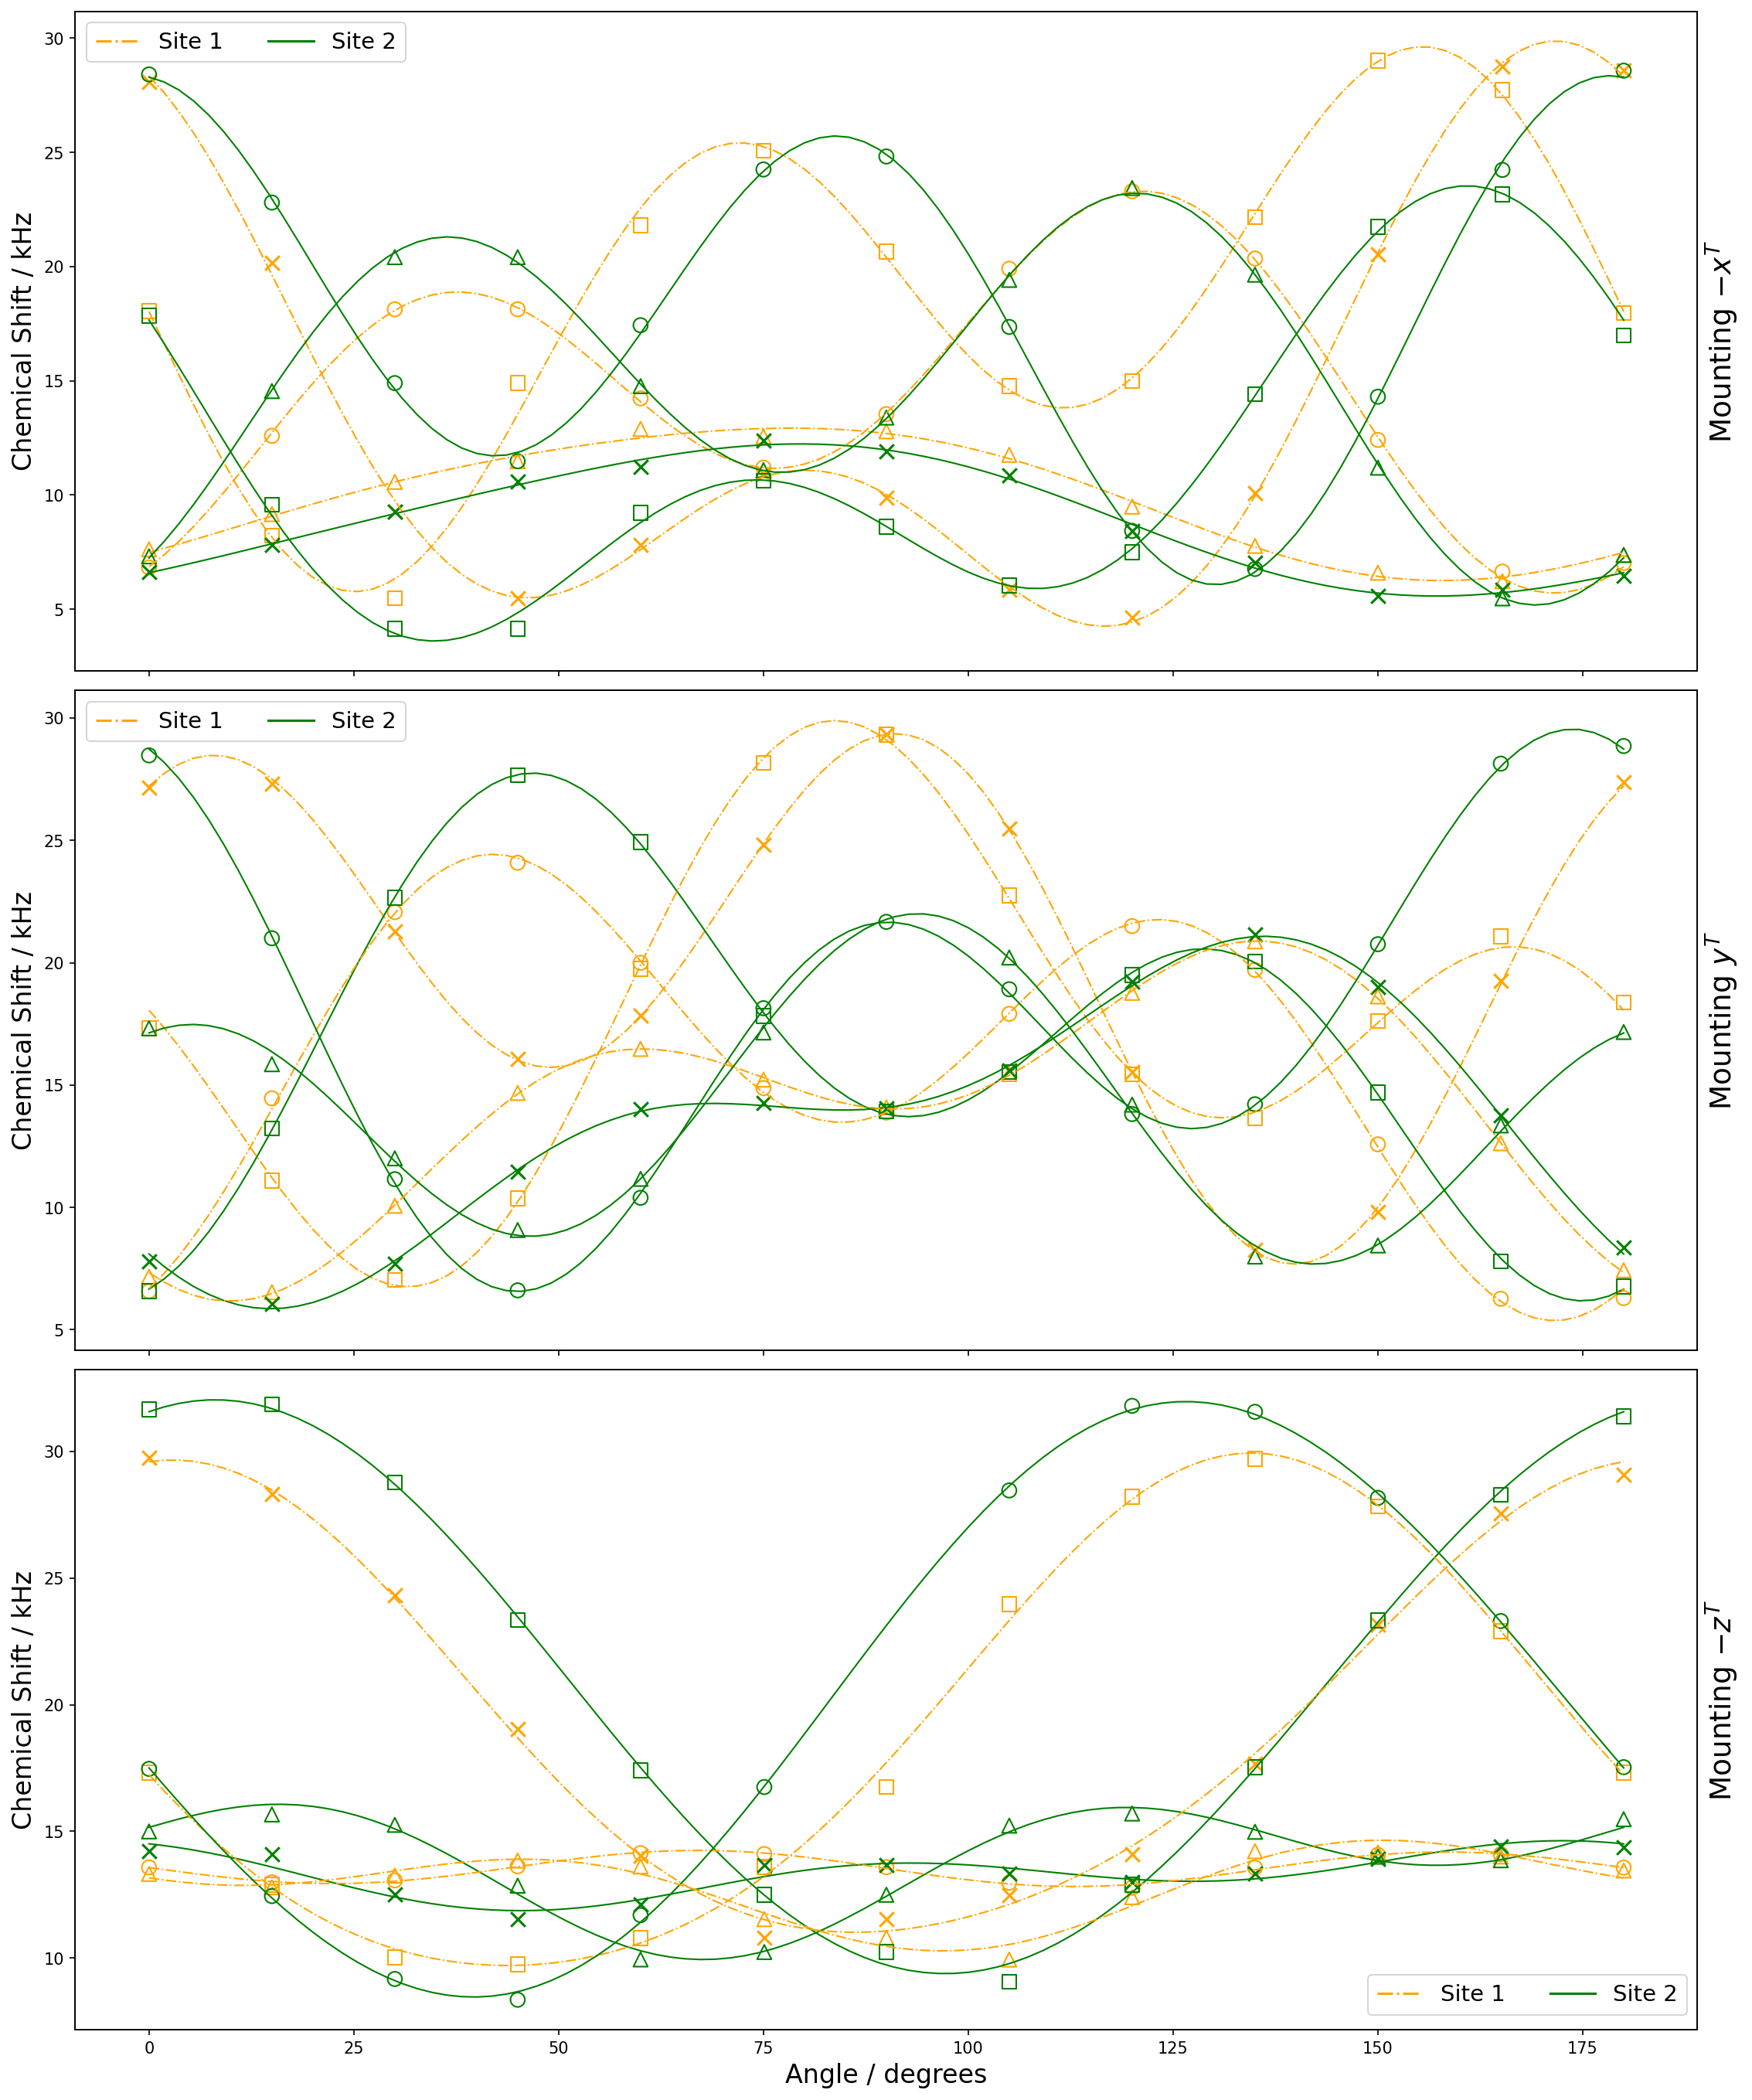

In [13]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
axes[0].scatter(df[0].angle, df[0].site1,  marker='o', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site2,  marker='s', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site3,  marker='^', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site4,  marker='x', s=80, c = 'orange') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site5,  marker='o', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site6,  marker='s', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site7,  marker='^', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[0].scatter(df[0].angle, df[0].site8,  marker='x', s=80, c = 'green') #frequency in kHz


axes[0].plot(angle_smooth, L_alanine_1_x,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_5_x,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_6_x,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_7_x,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_2_x,  color='green', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_3_x,  color='green', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_4_x,  color='green', lw = 1) #Fit line

axes[0].plot(angle_smooth, L_alanine_8_x,  color='green', lw = 1) #Fit line



# Plot Mount 2 data****************************

axes[1].scatter(df[1].angle, df[1].site1,  marker='o', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[1].scatter(df[1].angle, df[1].site2,  marker='s', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[1].scatter(df[1].angle, df[1].site3,  marker='^', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[1].scatter(df[1].angle, df[1].site4,  marker='x', s=80, c = 'orange') #frequency in kHz

axes[1].scatter(df[1].angle, df[1].site5,  marker='o', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[1].scatter(df[1].angle, df[1].site6,  marker='s', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[1].scatter(df[1].angle, df[1].site7,  marker='^', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[1].scatter(df[1].angle, df[1].site8,  marker='x', s=80, c = 'green') #frequency in kHz

axes[1].plot(angle_smooth, L_alanine_1_y,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[1].plot(angle_smooth, L_alanine_5_y,  color='green', lw = 1) #Fit line

axes[1].plot(angle_smooth, L_alanine_6_y,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[1].plot(angle_smooth, L_alanine_7_y,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[1].plot(angle_smooth, L_alanine_2_y,  color='green', lw = 1) #Fit line

axes[1].plot(angle_smooth, L_alanine_3_y,  color='green', lw = 1) #Fit line

axes[1].plot(angle_smooth, L_alanine_4_y,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[1].plot(angle_smooth, L_alanine_8_y,  color='green', lw = 1) #Fit line



# Plot Mount 3 data****************************

axes[2].scatter(df[2].angle, df[2].site1,  marker='o', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[2].scatter(df[2].angle, df[2].site2,  marker='s', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[2].scatter(df[2].angle, df[2].site3,  marker='^', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[2].scatter(df[2].angle, df[2].site4,  marker='x', s=80, c = 'orange') #frequency in kHz

axes[2].scatter(df[2].angle, df[2].site5,  marker='o', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[2].scatter(df[2].angle, df[2].site6,  marker='s', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[2].scatter(df[2].angle, df[2].site7,  marker='^', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[2].scatter(df[2].angle, df[2].site8,  marker='x', s=80, c = 'green') #frequency in kHz

axes[2].plot(angle_smooth, L_alanine_1_z,  color='green', lw = 1) #Fit line

axes[2].plot(angle_smooth, L_alanine_5_z,  color='green', lw = 1) #Fit line

axes[2].plot(angle_smooth, L_alanine_6_z,  color='green', lw = 1) #Fit line

axes[2].plot(angle_smooth, L_alanine_7_z,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[2].plot(angle_smooth, L_alanine_2_z,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[2].plot(angle_smooth, L_alanine_3_z,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[2].plot(angle_smooth, L_alanine_4_z,  color='green', lw = 1) #Fit line

axes[2].plot(angle_smooth, L_alanine_8_z,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

# Set x-axis label
plt.xlabel('Angle / degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[1].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[2].set_ylabel('Chemical Shift / kHz', fontsize=16)

# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel(r'Mounting $-x^T$', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel(r'Mounting $y^T$', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel(r'Mounting $-z^T$', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])


# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], color='orange', linestyle = 'dashdot', label='Site 1'),
                 Line2D([0], [0], color='green',  label='Site 2'),
                 
                 ]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=2)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=2)
axes[2].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0.79, 0.1), fontsize = 14, ncol=2)
# ax0_twin.set_xlim(left=-10)
# Save the plot
Fig.savefig('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/L_alanine_rotation_plot.png', dpi = 150 ,bbox_inches='tight')
# Show the plot
plt.show()


**For d-alanine**

In [6]:

D_alanine_x = [[14.658276, 7.216400, -3.116060, 1.490201, -7.189546], 
          [15.640840, 5.459443, -1.237210, 2.306491, -7.599776],
          [15.216576, 0.072022, -5.496262, -5.489084, -5.988805],
          [15.000989, 0.310786, -8.008707, -5.372655, -4.868097],
          [13.614125, -2.571057, 2.122641, 0.876060, 4.434248],
          [11.380562, -2.153674, 1.439551, 0.601109, 3.215899],
          [10.901631, -2.863134, 1.718526, 1.456839, 2.083045],
          [10.910626, -0.093337, 3.803955, 0.262706, 2.753496]
          ]                                                     # coefficient from ASICS
D_alanine_y = [[16.784983, -2.661461, 5.992598, -4.805244, 1.263909], 
          [15.507524, -1.637903, 5.970330, -2.771882, 2.324430],
          [17.302052, -1.318317, 4.257404, 5.317605, 2.946251],
          [18.356603, -2.320391, -4.822252, 6.522988, 0.922414],
          [17.243996 ,-1.313410 ,-6.044383 ,-4.351484 ,-3.784081],
          [15.822315 ,-0.693571 ,-5.212405 ,-1.637195 ,-4.577025],
          [15.061294 ,-8.969832, -3.202277 ,2.058323 ,4.017255],
          [13.269050, -7.786248, 0.597521, 3.756270, -0.997815]
          ]                                                     # coefficient from ASICS

D_alanine_z = [[17.703204, 5.262920, 10.763470, -0.296913, 0.450270], 
          [16.432790, 5.957978, 8.181473, 0.554587, 0.772797],
          [17.943443 ,10.674556 ,-5.692665, 0.158719, -0.637730],
          [16.470580 ,10.098400, -3.541080, 1.142753, 0.381976],
          [15.639247, -0.358432, 3.834809, -0.927770, -2.244316],
          [15.034906, -1.941974, 2.056205, 1.290379, -0.924511],
          [14.973226, -0.336538, -2.653379, -0.337275, 1.642036],
          [15.462345, 1.933536, -3.015177, -2.565881, -0.060757]
          ]                                                     # coefficient from ASICS

# # Fit for Mounting 1

angle_smooth = np.linspace(df[3].angle.min(), df[3].angle.max(), 100) #100 points for smooth curve
D_alanine_1_x = fourier5(angle_smooth, *D_alanine_x[0])
D_alanine_2_x = fourier5(angle_smooth, *D_alanine_x[1])
D_alanine_3_x = fourier5(angle_smooth, *D_alanine_x[2])
D_alanine_4_x = fourier5(angle_smooth, *D_alanine_x[3])
D_alanine_5_x = fourier5(angle_smooth, *D_alanine_x[4])
D_alanine_6_x = fourier5(angle_smooth, *D_alanine_x[5])
D_alanine_7_x = fourier5(angle_smooth, *D_alanine_x[6])
D_alanine_8_x = fourier5(angle_smooth, *D_alanine_x[7])


# # Fit for Mounting 2

D_alanine_1_y = fourier5(angle_smooth, *D_alanine_y[0])
D_alanine_2_y = fourier5(angle_smooth, *D_alanine_y[1])
D_alanine_3_y = fourier5(angle_smooth, *D_alanine_y[2])
D_alanine_4_y = fourier5(angle_smooth, *D_alanine_y[3])
D_alanine_5_y = fourier5(angle_smooth, *D_alanine_y[4])
D_alanine_6_y = fourier5(angle_smooth, *D_alanine_y[5])
D_alanine_7_y = fourier5(angle_smooth, *D_alanine_y[6])
D_alanine_8_y = fourier5(angle_smooth, *D_alanine_y[7])

# # Fit for Mounting 3
D_alanine_1_z = fourier5(angle_smooth, *D_alanine_z[0])
D_alanine_2_z = fourier5(angle_smooth, *D_alanine_z[1])
D_alanine_3_z = fourier5(angle_smooth, *D_alanine_z[2])
D_alanine_4_z = fourier5(angle_smooth, *D_alanine_z[3])
D_alanine_5_z = fourier5(angle_smooth, *D_alanine_z[4])
D_alanine_6_z = fourier5(angle_smooth, *D_alanine_z[5])
D_alanine_7_z = fourier5(angle_smooth, *D_alanine_z[6])
D_alanine_8_z = fourier5(angle_smooth, *D_alanine_z[7])


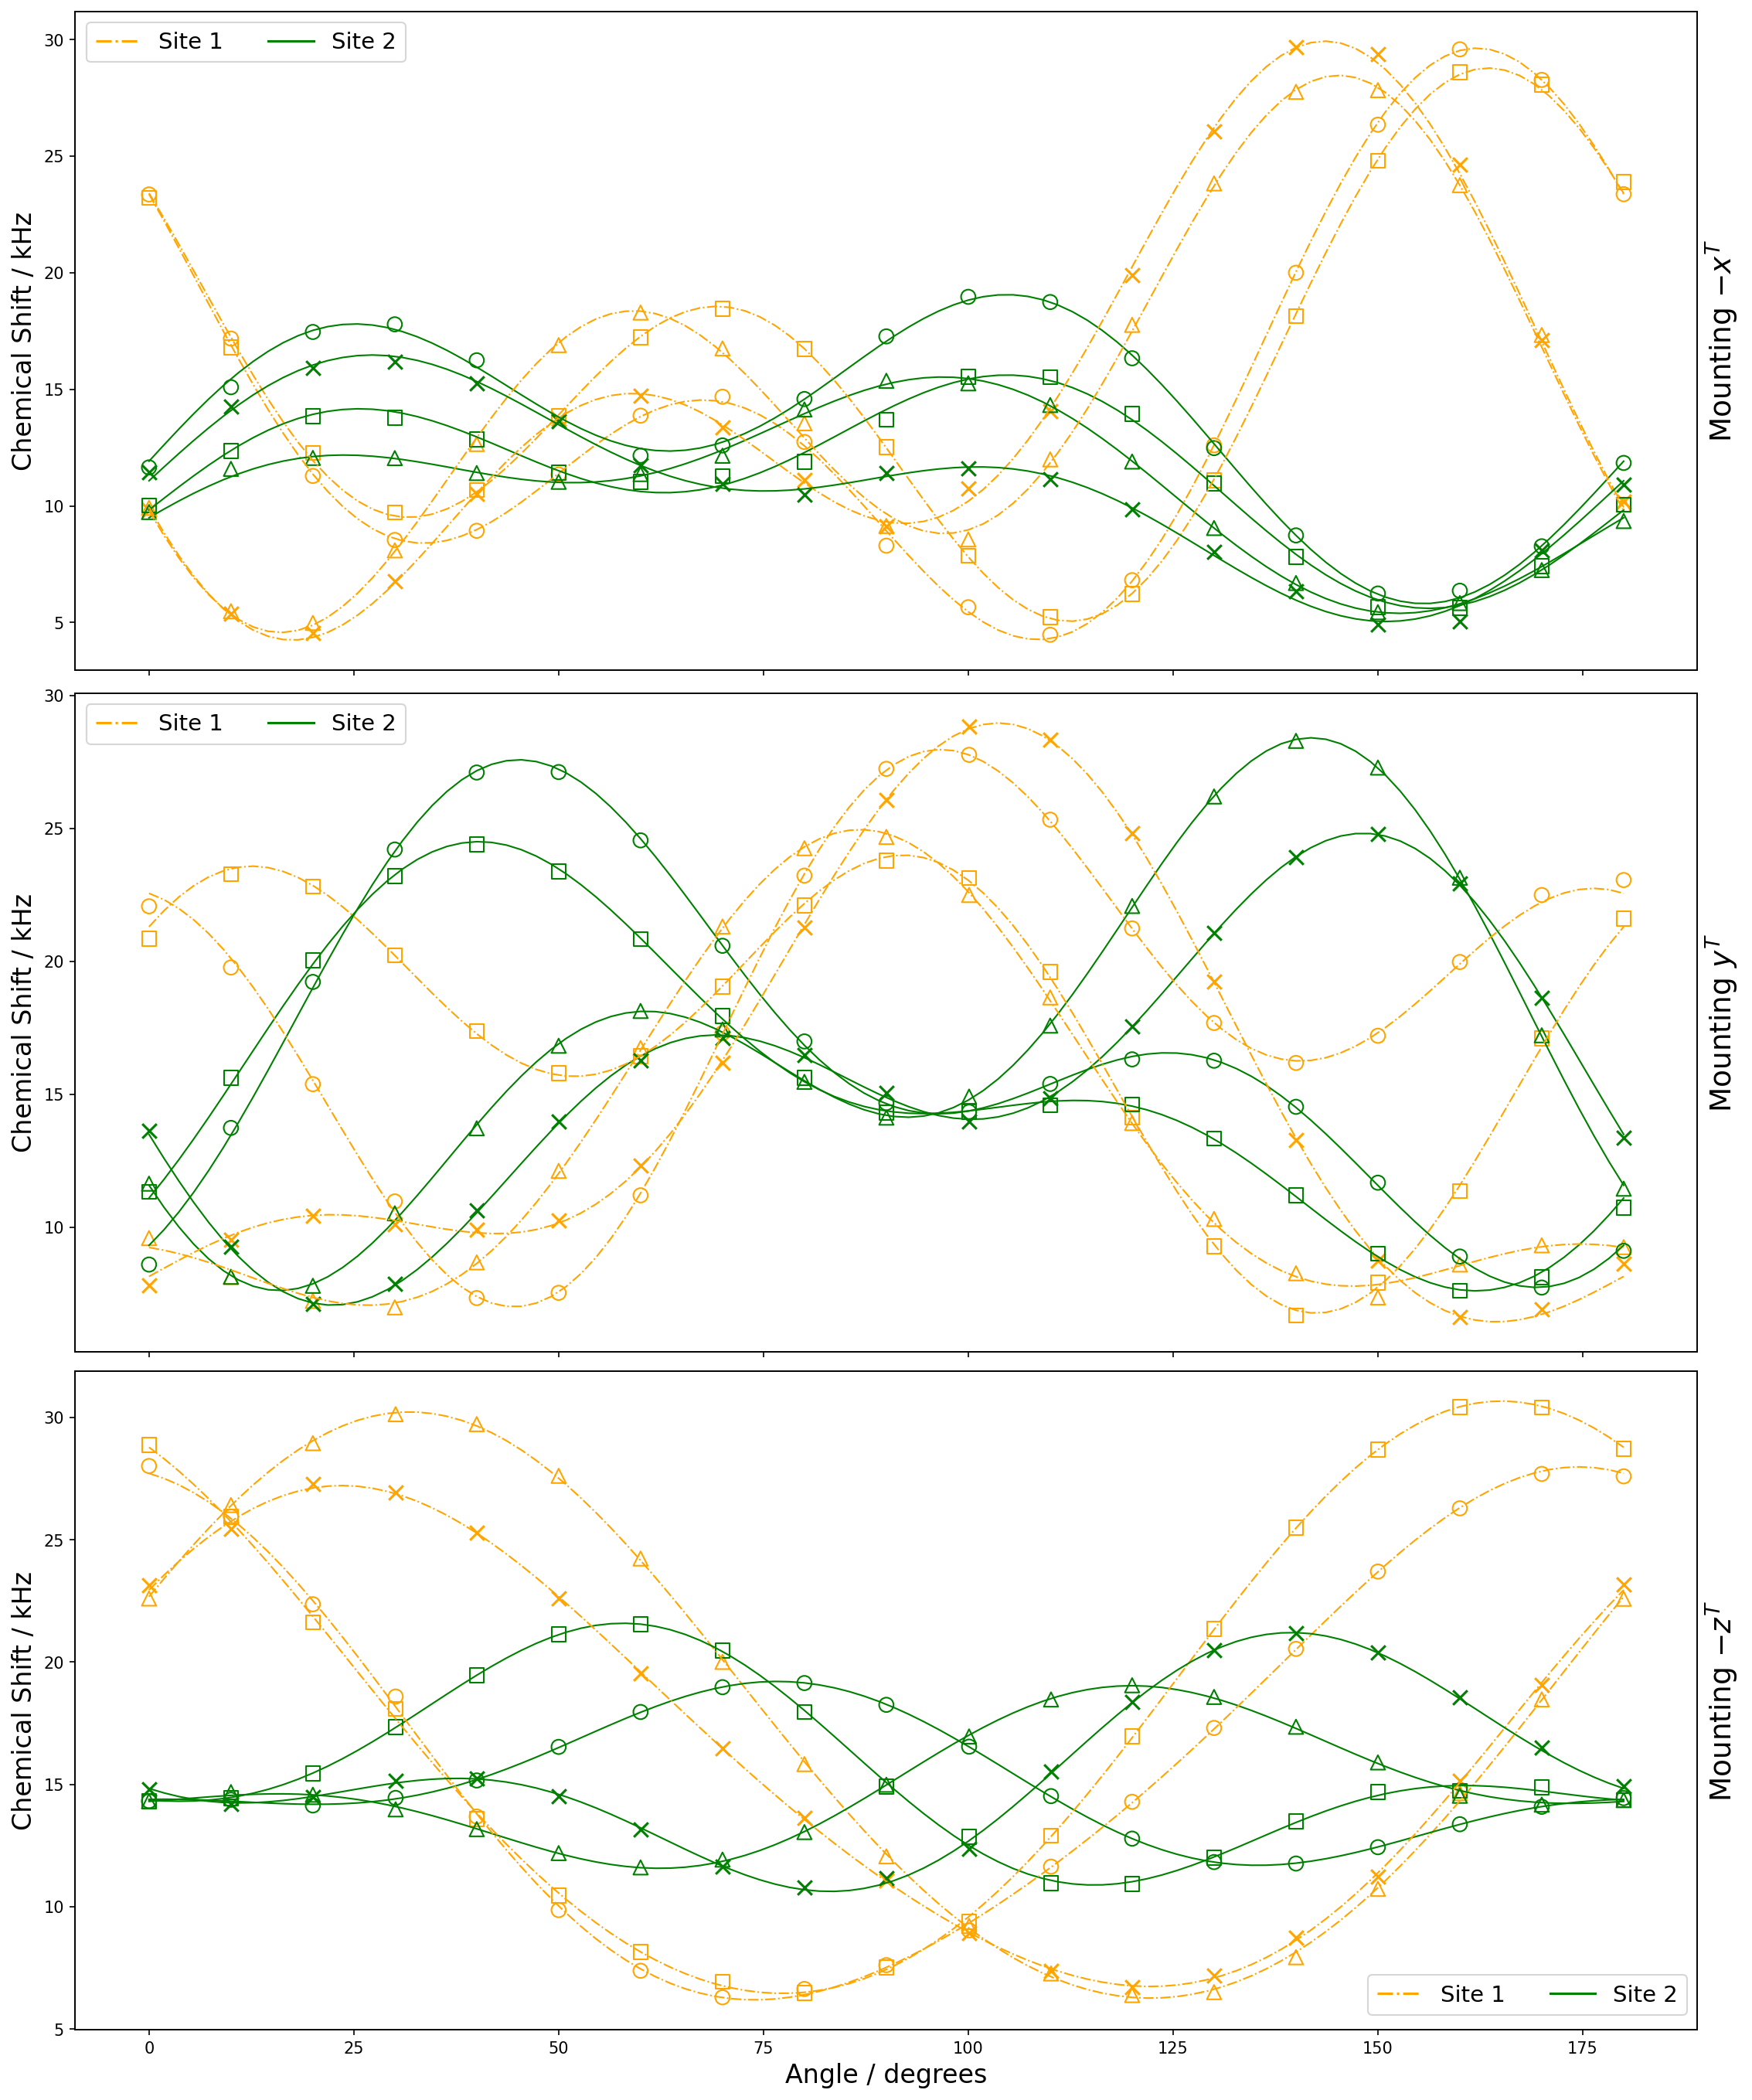

In [20]:
# Plot Site 1 and Site 2 together
Fig, axes = plt.subplots(nrows=3, ncols=1,figsize=(15,18), dpi =  150, sharex=True, sharey='row', constrained_layout=True)
# Fig.suptitle(r'$(-,-)8HQ(ipc)_2B\ $Rotation Plot', fontweight = "bold", fontsize=20)

# Plot Mount 1 data****************************
axes[0].scatter(df[3].angle, df[3].site1,  marker='o', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[0].scatter(df[3].angle, df[3].site2,  marker='s', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[0].scatter(df[3].angle, df[3].site3,  marker='^', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[0].scatter(df[3].angle, df[3].site4,  marker='x', s=80, c = 'orange') #frequency in kHz

axes[0].scatter(df[3].angle, df[3].site5,  marker='o', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[0].scatter(df[3].angle, df[3].site6,  marker='s', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[0].scatter(df[3].angle, df[3].site7,  marker='^', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[0].scatter(df[3].angle, df[3].site8,  marker='x', s=80, c = 'green') #frequency in kHz


axes[0].plot(angle_smooth, D_alanine_1_x,  color = 'orange', linestyle = 'dashdot',  lw = 1) #Fit line

axes[0].plot(angle_smooth, D_alanine_5_x,  color='green', lw = 1) #Fit line

axes[0].plot(angle_smooth, D_alanine_6_x,  color='green', lw = 1) #Fit line

axes[0].plot(angle_smooth, D_alanine_7_x,  color='green', lw = 1) #Fit line

axes[0].plot(angle_smooth, D_alanine_2_x,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[0].plot(angle_smooth, D_alanine_3_x,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[0].plot(angle_smooth, D_alanine_4_x,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[0].plot(angle_smooth, D_alanine_8_x,  color='green', lw = 1) #Fit line



# Plot Mount 2 data****************************

axes[1].scatter(df[4].angle, df[4].site1,  marker='o', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[1].scatter(df[4].angle, df[4].site2,  marker='s', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[1].scatter(df[4].angle, df[4].site3,  marker='^', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[1].scatter(df[4].angle, df[4].site4,  marker='x', s=80, c = 'orange') #frequency in kHz

axes[1].scatter(df[4].angle, df[4].site5,  marker='o', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[1].scatter(df[4].angle, df[4].site6,  marker='s', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[1].scatter(df[4].angle, df[4].site7,  marker='^', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[1].scatter(df[4].angle, df[4].site8,  marker='x', s=80, c = 'green') #frequency in kHz

axes[1].plot(angle_smooth, D_alanine_1_y,  color='green', lw = 1) #Fit line

axes[1].plot(angle_smooth, D_alanine_5_y,  color='green', lw = 1) #Fit line

axes[1].plot(angle_smooth, D_alanine_6_y,  color='green', lw = 1) #Fit line

axes[1].plot(angle_smooth, D_alanine_7_y,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[1].plot(angle_smooth, D_alanine_2_y,  color='green', lw = 1) #Fit line

axes[1].plot(angle_smooth, D_alanine_3_y,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[1].plot(angle_smooth, D_alanine_4_y,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[1].plot(angle_smooth, D_alanine_8_y,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line



# Plot Mount 3 data****************************

axes[2].scatter(df[5].angle, df[5].site1,  marker='o', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[2].scatter(df[5].angle, df[5].site2,  marker='s', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[2].scatter(df[5].angle, df[5].site3,  marker='^', s=80, facecolor='none', edgecolor='orange') #frequency in kHz

axes[2].scatter(df[5].angle, df[5].site4,  marker='x', s=80, c = 'orange') #frequency in kHz

axes[2].scatter(df[5].angle, df[5].site5,  marker='o', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[2].scatter(df[5].angle, df[5].site6,  marker='s', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[2].scatter(df[5].angle, df[5].site7,  marker='^', s=80, facecolor='none', edgecolor='green') #frequency in kHz

axes[2].scatter(df[5].angle, df[5].site8,  marker='x', s=80, c = 'green') #frequency in kHz

axes[2].plot(angle_smooth, D_alanine_1_z,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[2].plot(angle_smooth, D_alanine_5_z,  color='green', lw = 1) #Fit line

axes[2].plot(angle_smooth, D_alanine_6_z,  color='green', lw = 1) #Fit line

axes[2].plot(angle_smooth, D_alanine_7_z,  color='green', lw = 1) #Fit line

axes[2].plot(angle_smooth, D_alanine_2_z,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[2].plot(angle_smooth, D_alanine_3_z,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[2].plot(angle_smooth, D_alanine_4_z,  color = 'orange', linestyle = 'dashdot', lw = 1) #Fit line

axes[2].plot(angle_smooth, D_alanine_8_z,  color='green', lw = 1) #Fit line

# Set x-axis label
plt.xlabel('Angle / degrees', fontsize=16)

# Left-side label for Chemical Shift (only on axes[0])
axes[0].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[1].set_ylabel('Chemical Shift / kHz', fontsize=16)
axes[2].set_ylabel('Chemical Shift / kHz', fontsize=16)

# Right-side labels for Mount 1 , Mount 2, Mount 3 using twin axes
ax0_twin = axes[0].twinx()
ax0_twin.set_ylabel(r'Mounting $-x^T$', fontsize=18)
ax0_twin.yaxis.set_label_position("right")
ax0_twin.yaxis.set_ticks([])

ax1_twin = axes[1].twinx()
ax1_twin.set_ylabel(r'Mounting $y^T$', fontsize=18)
ax1_twin.yaxis.set_label_position("right")
ax1_twin.yaxis.set_ticks([])

ax2_twin = axes[2].twinx()
ax2_twin.set_ylabel(r'Mounting $-z^T$', fontsize=18)
ax2_twin.yaxis.set_label_position("right")
ax2_twin.yaxis.set_ticks([])

# Custom legend handle ( markers)
marker_legend1 = [Line2D([0], [0], color='orange', linestyle = 'dashdot', label='Site 1'),
                 Line2D([0], [0], color='green',  label='Site 2'),
                 
                 ]

marker_legend2 = []

combined_legend = marker_legend1 + marker_legend2
# Add a single legend with both markers and lines, placed side by side
axes[0].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=2)
axes[1].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0, 1), fontsize = 14, ncol=2)
axes[2].legend(handles=combined_legend, loc='upper left', bbox_to_anchor=(0.79, 0.1), fontsize = 14, ncol=2)
# ax0_twin.set_xlim(left=-10)
# Save the plot
Fig.savefig('/home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/NMR_analysis/plots_experiment/D_alanine_rotation_plot.png', dpi = 150 ,bbox_inches='tight')
# Show the plot
plt.show()
